# Overview

In this script we aim to get an overview of how long the cases are. 

In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# show all outputs of cell, not merely of last line (i.e. default of Jupyter Notebook)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
# change working directory + set download location
data_location = "../data"
overview_filename = 'CC_2025-2025.pkl'
lenghts_filename = 'lengths_texts.pkl'

In [4]:
# read in main data file
overview_df = pd.read_pickle(os.path.join(data_location, overview_filename))
overview_df.head()


,case number,role number,date,type procedure,controlled norm,outcome,keywords,url
0,61/2025,[8423],03/04/2025,Beroep tot vernietiging,Wetten en procedures inzake gedeeltelijke verb...,Verwerping van het beroep,"[Voorafgaande rechtspleging, Beroep tot vernie...",www.const-court.be/public/n/2025/2025-061n.pdf
1,60/2025,[8286],03/04/2025,Prejudiciële vraag,"Wetboek van economisch recht (artikel I.1, eer...",Onontvankelijkheid van de prejudiciële vraag,"[Economisch recht, Insolventie van onderneming...",www.const-court.be/public/n/2025/2025-060n.pdf
2,59/2025,[8285],03/04/2025,Beroep tot vernietiging,Ordonnantie van het Brusselse Hoofdstedelijke ...,Vernietiging,"[Fiscaal recht, Registratierechten, Brusselse ...",www.const-court.be/public/n/2025/2025-059n.pdf
3,58/2025,[8266],03/04/2025,Beroep tot vernietiging,Programmawet van 22 december 2023 (artikel 114),Verwerping van het beroep,"[Sociaal recht, Sociale zekerheid, Ziekte- en ...",www.const-court.be/public/n/2025/2025-058n.pdf
4,57/2025,"[8224, 8223]",03/04/2025,Prejudiciële vragen,Wet van 17 april 1878 « houdende de voorafgaan...,Geen schending (artikel 26 van de wet van 17 a...,"[Sociale zekerheid, Ziekte- en invaliditeitsve...",www.const-court.be/public/n/2025/2025-057n.pdf


In [5]:
# Extract case number (i.e. everything between final slash and .pdf) from url and store it in a new column
overview_df['case_number'] = overview_df['url'].str.extract(r'([^/]+)\.pdf$')[0]
# Check if the new column was created correctly
overview_df['case_number'].head()

0    2025-061n
1    2025-060n
2    2025-059n
3    2025-058n
4    2025-057n
Name: case_number, dtype: object

In [6]:
# read in lenghts of texts
lenghts_df = pd.read_pickle(os.path.join(data_location, lenghts_filename))
lenghts_df.head()

,case_number,word_count
0,2025-001n,5215
1,2025-002n,2795
2,2025-003n,16487
3,2025-004n,4489
4,2025-005n,34395


In [7]:
# Merge the two dataframes on the 'casenumber' column using inner join
merged_df = pd.merge(overview_df, lenghts_df, left_on='case_number', right_on='case_number', how='inner')
# Check the merged dataframe
merged_df.head()
# Check the number of rows in the merged dataframe
len(merged_df)
# Check the number of rows in the original dataframe
len(overview_df)

,case number,role number,date,type procedure,controlled norm,outcome,keywords,url,case_number,word_count
0,61/2025,[8423],03/04/2025,Beroep tot vernietiging,Wetten en procedures inzake gedeeltelijke verb...,Verwerping van het beroep,"[Voorafgaande rechtspleging, Beroep tot vernie...",www.const-court.be/public/n/2025/2025-061n.pdf,2025-061n,718
1,60/2025,[8286],03/04/2025,Prejudiciële vraag,"Wetboek van economisch recht (artikel I.1, eer...",Onontvankelijkheid van de prejudiciële vraag,"[Economisch recht, Insolventie van onderneming...",www.const-court.be/public/n/2025/2025-060n.pdf,2025-060n,1877
2,59/2025,[8285],03/04/2025,Beroep tot vernietiging,Ordonnantie van het Brusselse Hoofdstedelijke ...,Vernietiging,"[Fiscaal recht, Registratierechten, Brusselse ...",www.const-court.be/public/n/2025/2025-059n.pdf,2025-059n,3137
3,58/2025,[8266],03/04/2025,Beroep tot vernietiging,Programmawet van 22 december 2023 (artikel 114),Verwerping van het beroep,"[Sociaal recht, Sociale zekerheid, Ziekte- en ...",www.const-court.be/public/n/2025/2025-058n.pdf,2025-058n,6941
4,57/2025,"[8224, 8223]",03/04/2025,Prejudiciële vragen,Wet van 17 april 1878 « houdende de voorafgaan...,Geen schending (artikel 26 van de wet van 17 a...,"[Sociale zekerheid, Ziekte- en invaliditeitsve...",www.const-court.be/public/n/2025/2025-057n.pdf,2025-057n,5966


61

61

In [10]:
# Save merged dataframe to a new pickle file
merged_filename = overview_filename.replace('.pkl', '_merged.pkl')
merged_df.to_pickle(os.path.join(data_location, merged_filename))

## Size of cases

<Axes: xlabel='word_count', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Text Lengths')

Text(0.5, 0, 'Length of Texts')

Text(0, 0.5, 'Frequency')

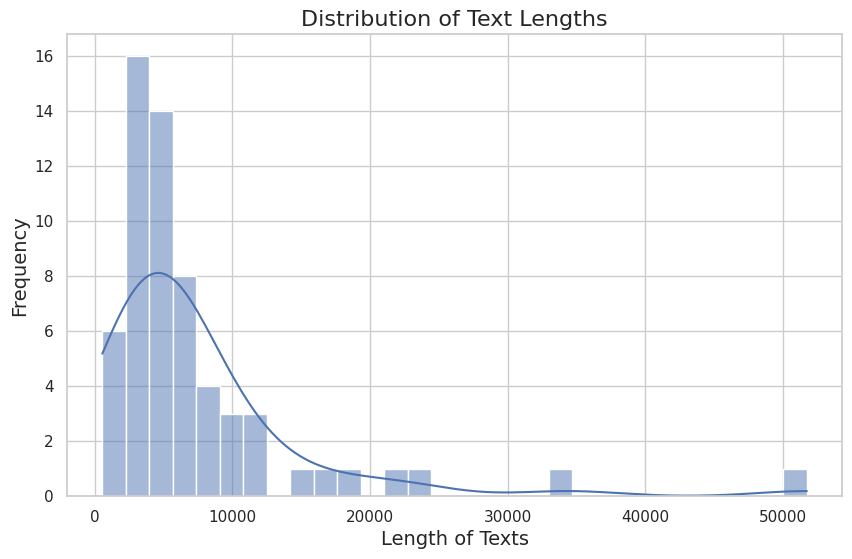

In [9]:
# Plot the distribution of the lengths of the texts
# Set the style of seaborn
sns.set(style="whitegrid")
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
# Create a histogram of the lengths of the texts
sns.histplot(merged_df['word_count'], bins=30, kde=True, ax=ax)
# Set the title and labels
ax.set_title('Distribution of Text Lengths', fontsize=16)
ax.set_xlabel('Length of Texts', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
# Show the plot
plt.show()